In [ ]:
from src.data import DataPreparator, CachedCollection, LazyLoadCollection, PKSampler
from src.distances.index import BinaryStrategy, SparseIndex, DenseIndex
from src.distances.kernels import BinaryJaccardKernel, BhattacharyyaKernel, EuclidianDistanceKernel
from src.distances.fusion import RRFBasedFusion
from src.models.rerankers import ORBReranker, HSVReranker
from src.models.feature_extractors import DocTRTextExtractor, HSVExtractor, OrbFeatureExtractor, SiameseDino
from src.models.cvmodels import FeatureBasedEstimator
from src.feature_stores import InMemoryStore
from src.eval import Recall
from src.preprocess import PolarTransform, YOLOCustomCrop
from src.types import RetrievalChannel

from torch.utils.data import DataLoader
from torchvision.transforms import v2
from pathlib import Path
from PIL import Image
import numpy as np

/home/timothee/anaconda3/envs/DIHT/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/timothee/anaconda3/envs/DIHT/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened bec

In [ ]:
AUGMENTED_DATA_PATH = Path("/home/timothee/Documents/programmation/DIHT/data/original_data")
ORIGINAL_DATA_PATH = Path("/home/timothee/Documents/programmation/DIHT/data/original_data")

In [ ]:
train_ratio = 0.7
val_ratio = 0.3
max_gallery_instances = 1
n_query = 1

In [ ]:
dp = DataPreparator(ORIGINAL_DATA_PATH, AUGMENTED_DATA_PATH)

Found 101 total classes.


In [ ]:
splits = dp.train_val_test_split(train_ratio, val_ratio, max_gallery_instances, n_query)

Processing Train classes...
Processing Validation classes...
Processing Test classes...

--- Data Split Summary ---
Training Loader:     281 samples from 70 classes (Augmented)
Gallery Loader:      101 samples from 101 classes (Original)
Val Query Loader:     30 samples from 30 classes (Original)
Test Query Loader:     1 samples from 1 classes (Original)


In [ ]:
train_paths, train_labels = splits["train"]
gallery_paths, gallery_labels = splits["gallery"]
query_paths, query_labels = splits["val_query"]

In [ ]:
def labelset(paths) -> set:
    s = set()
    for path in paths:
        label = path.split('/')[-2]
        s.add(label)

    return s

print(len(labelset(gallery_paths).intersection(labelset(query_paths))))

30


In [ ]:
crop = YOLOCustomCrop("runs/segment/train-3/weights/best.pt")
polar = PolarTransform()
resize = v2.Resize((640, 640))
preprocessor = v2.Compose([crop, polar, resize])

In [ ]:
train_transforms = v2.Compose([                           
        #v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0), 
        v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 0.9)),
        v2.RandomRotation(degrees=15),
    ])

In [ ]:
cutoff = 10
gallery_dataset = CachedCollection(gallery_paths[:cutoff],
                                   gallery_labels[:cutoff],
                                   preprocessor=preprocessor)
query_dataset = CachedCollection(query_paths[:cutoff],
                                 query_labels[:cutoff],
                                 preprocessor=preprocessor)
train_dataset = CachedCollection(train_paths[:cutoff],
                                 train_labels[:cutoff],
                                 preprocessor=preprocessor,
                                 transform=train_transforms)

In [ ]:
from src.config import load_config

cfg = load_config("../config/config.yaml")

print(cfg.train.epochs)       # 20
print(cfg.model.backbone_name) # facebook/dinov2-base
print(cfg.base.device)         # cuda

20
facebook/dinov3-vitb16-pretrain-lvd1689m
gpu


In [ ]:
def numpy_collate(batch):
    elem = batch[0]
    if isinstance(elem, np.ndarray):
        return np.stack(batch)
    elif isinstance(elem, dict):
        return {k: numpy_collate([d[k] for d in batch]) for k in elem}
    elif isinstance(elem, (tuple, list)):
        return type(elem)(numpy_collate(s) for s in zip(*batch))
    else:
        return batch  # fallback: plain list
    
pk_sampler = PKSampler(train_dataset, cfg.train.sampler_P, cfg.train.sampler_K)

gallery_dataloader = DataLoader(gallery_dataset, batch_size=32, collate_fn=numpy_collate)
query_dataloader = DataLoader(query_dataset, batch_size=32, collate_fn=numpy_collate)
train_dataloader = DataLoader(train_dataset, batch_sampler=pk_sampler, collate_fn=numpy_collate)

In [ ]:
import torch

fs = InMemoryStore()


bs = BinaryStrategy()
bin_kernel = BinaryJaccardKernel()
tcsr = SparseIndex(bin_kernel, bs)
ocr = DocTRTextExtractor()
channel1 = RetrievalChannel(ocr, tcsr, bin_kernel)

bhatt_kernel = BhattacharyyaKernel()
di_hsv = DenseIndex(bhatt_kernel)
hsv = HSVExtractor()
channel2 = RetrievalChannel(hsv, di_hsv, bhatt_kernel)

euclidian_kernel = EuclidianDistanceKernel()
di_sd = DenseIndex(euclidian_kernel)
siamese_model = SiameseDino(cfg)

for param in siamese_model._backbone.parameters():
    param.requires_grad = False
for param in siamese_model._backbone.layer[-2:].parameters():
    param.requires_grad = True
    
optim_params = [
    {"params": siamese_model.projection_head.parameters(), "lr": cfg.train.head_lr},
    {"params": siamese_model._backbone.layer[-2:].parameters(), "lr": cfg.train.backbone_lr}
]

optimizer = torch.optim.Adam(optim_params, weight_decay=cfg.train.weight_decay)
siamese_model.set_optimizer(optimizer)
channel3 = RetrievalChannel(siamese_model, di_sd, euclidian_kernel, is_trainable=True)


fusion = RRFBasedFusion()
channels = [channel3]

orb = OrbFeatureExtractor(500)
reranker = ORBReranker(orb)
hsv_reranker = HSVReranker()
top_k = 10

fbe = FeatureBasedEstimator(preprocessor, channels, fs, fusion, reranker=hsv_reranker, top_k_candidates=top_k)
#fbe = FeatureBasedEstimator(preprocessor, channels, fs, fusion, reranker=reranker, top_k_candidates=top_k)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Currently logged in as: entropeaks (entropeaks-universit-paul-sabatier-toulouse-iii) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
metric = Recall(recall_k=[1, 3, 10])
fbe.fit(train_dataloader)
fbe.evaluate(gallery_dataloader, query_dataloader, metric)

--------------- Training Siamese model ---------------


  5%|▌         | 1/20 [01:08<21:36, 68.22s/it]

Epoch 1: {'loss': 0.021606434136629105, 'positive_dist': 0.41755687445402145, 'negative_dist': 0.6209504306316376, 'triplets_mined': 113}


 10%|█         | 2/20 [02:09<19:12, 64.03s/it]

Epoch 2: {'loss': 0.002157408744096756, 'positive_dist': 0.13593995571136475, 'negative_dist': 0.20878253877162933, 'triplets_mined': 4}


...

Epoch 20: {'loss': 0.0184276863001287, 'positive_dist': 0.4266171082854271, 'negative_dist': 0.7081894278526306, 'triplets_mined': 38}


Computing queries features...


Computing features blocks: 100%|██████████| 1/1 [00:03<00:00,  3.11s/it]


Feature 0: min=0.5773, max=1.7870, std=0.1746, mean=1.3766
Feature 0 after norm: min=61.0000, max=161.0000, std=29.1596, mean=111.0000
[[        135         158          69 ...         109         128         152]
 [        109          92          72 ...         135          73         161]
 [        130         116          94 ...         119         158         127]
 ...
 [        151         145          62 ...         118         153         160]
 [        140         143         110 ...          61         117         105]
 [         91          80          99 ...         132          61         139]]
Scores before reranking:
{'recall@1': 0.7666666666666667, 'recall@3': 0.9, 'recall@10': 0.9666666666666667}
Scores after reranking:
{'recall@1': 0.6, 'recall@3': 0.9, 'recall@10': 0.9666666666666667}
Elapsed time for evaluate = 4.66s
Energy consumption for evaluate = 0.000098 kWh
Carbon footprint for evaluate = 0.000005 g.eq.CO2


{'recall@1': 0.6, 'recall@3': 0.9, 'recall@10': 0.9666666666666667}

In [ ]:
fbe._channels[0].extractor._fit_one_epoch(train_dataloader)

ZeroDivisionError: float division by zero

In [ ]:
query_labels = torch.tensor(query_dataloader.dataset.labels)
gallery_labels = torch.tensor(gallery_dataloader.dataset.labels)

query_paths = query_dataloader.dataset.images_paths
gallery_paths = gallery_dataloader.dataset.images_paths

print("Computing queries features...")
query_features = fbe._compute_features(query_dataloader, update_index=False)

dists = fbe._compute_distances(query_features)

k = 1

topk_indices = torch.from_numpy(dists).topk(k, largest=False).indices

l = []

for i, q_label in enumerate(query_labels):
    gallery_indices = topk_indices[i, :k]
    retrieved_labels = gallery_labels[gallery_indices]
    max_gallery_idx = gallery_indices[0]
    if q_label not in retrieved_labels:
        l.append((query_paths[i], gallery_paths[max_gallery_idx]))
    

Computing queries features...


Computing features blocks: 100%|██████████| 1/1 [00:03<00:00,  3.15s/it]

Feature 0: min=0.5786, max=1.7872, std=0.1738, mean=1.3766
Feature 0 after norm: min=61.0000, max=161.0000, std=29.1596, mean=111.0000
[[        135         158          70 ...         110         127         149]
 [        107          90          73 ...         134          72         161]
 [        127         110          94 ...         121         158         132]
 ...
 [        153         144          62 ...         122         155         160]
 [        141         144         110 ...          61         118         105]
 [         91          80          98 ...         138          61         142]]


In [ ]:
len(l)

7

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

def show_images(paths: list[str] | list[Image.Image], cols: int = 3, figsize_per_image: tuple = (4, 4)) -> None:
    """
    Affiche une liste d'images sur une figure matplotlib.

    Args:
        paths: Liste des chemins vers les images ou objets PIL Image.
        cols: Nombre de colonnes dans la grille (défaut: 3).
        figsize_per_image: Taille (largeur, hauteur) par image en pouces.
    """
    n = len(paths)
    if n == 0:
        print("Aucune image à afficher.")
        return

    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(figsize_per_image[0] * cols, figsize_per_image[1] * rows)
    )

    # Normalise axes en tableau 1D
    axes = [axes] if n == 1 else list(axes.flat)

    for ax, path in zip(axes, paths):
        try:
            if isinstance(path, Image.Image):
                img = path
                title = getattr(path, "filename", None)
                title = title.split("/")[-1] if title else "PIL Image"
            else:
                img = Image.open(path)
                title = path.split("/")[-1]

            ax.imshow(img)
            ax.set_title(title, fontsize=9)
        except Exception as e:
            ax.text(0.5, 0.5, f"Erreur:\n{e}", ha="center", va="center", color="red")
        ax.axis("off")

    # Cache les axes inutilisés si la grille n'est pas pleine
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
from transformers.image_utils import load_image

path = "/home/timothee/Documents/programmation/DIHT/data/test_data/IMG_2939.jpg"
img = load_image(path)
img = preprocessor(img)
img = np.array(img)

query_features = fbe._compute_features([[[img], []]], update_index=True)
fs.add(path, query_features[0])

Computing features blocks: 100%|██████████| 1/1 [00:00<00:00,  8.98it/s]


Computing features blocks: 100%|██████████| 1/1 [00:00<00:00,  8.08it/s]


Feature 0: min=0.6044, max=1.7022, std=0.1507, mean=1.3414
Feature 0 after norm: min=61.0000, max=162.0000, std=29.5888, mean=111.5000
[[        134         102          63          71         139         144          84          92         133          72          69         160         117         154         158          93         115         101          80          70         121         157          95         116         113          75
           66         142          68         150         125          79         146         145         155         126         140         123         147          97         161         138          76         107          94         135         111         103         152         109         124         159
          105          64          98         130          82         110         114         137          65         132         151         122         148          83         149          96          77          91          87        

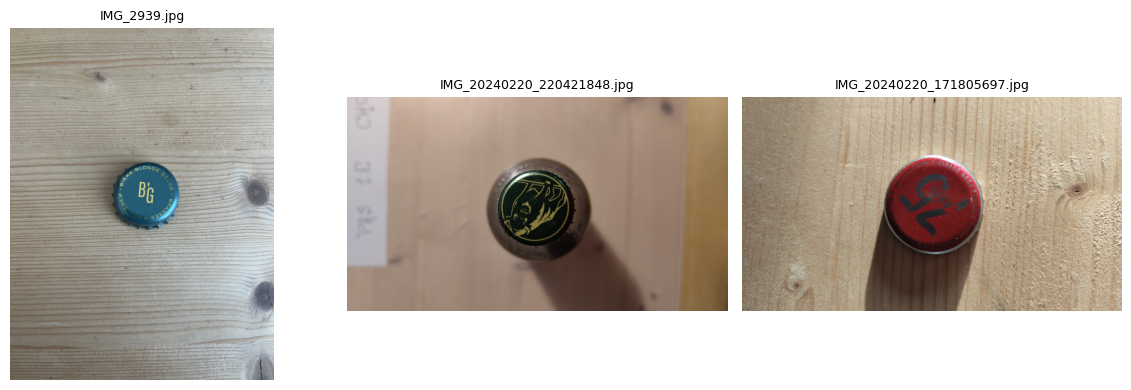

In [ ]:
path = "/home/timothee/Documents/programmation/DIHT/data/test_data/IMG_2941.jpg"
fbe._reranker = None
show_images(fbe.find_nearest_neighbors(path, 3))

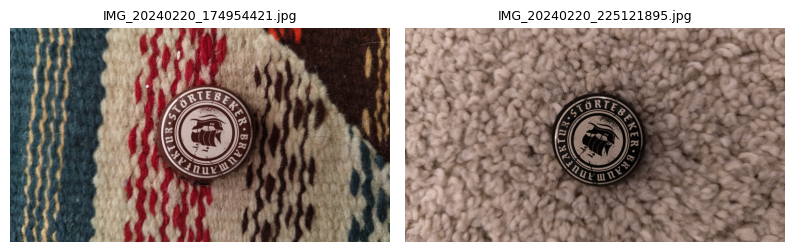

In [ ]:
p = 2
show_images(l[p])

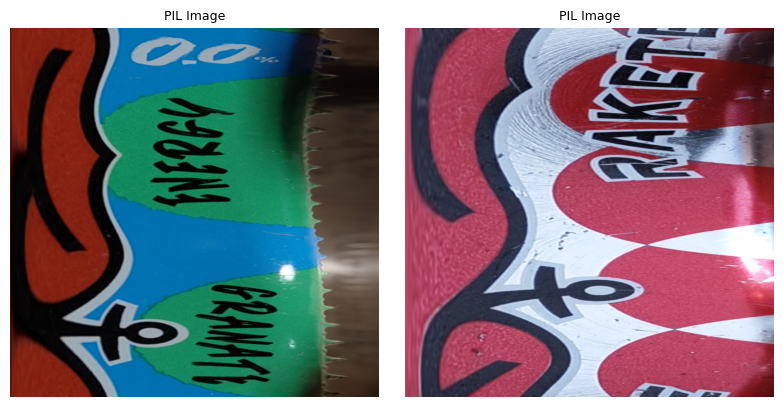

In [ ]:
img_ref = Image.open(l[p][0])
img_comp = Image.open(l[p][1])
show_images([preprocessor(img_ref), preprocessor(img_comp)])